# Classificazione dell'Abbandono Aziendale (Employee Attrition): Data classification
**Business Intelligence per Big Data — Politecnico di Torino, AA 2025-2026**

**Obiettivo:** predire se un dipendente lascerà l'azienda (Attrition = 1) o rimarrà (Attrition = 0), usando algoritmi di classificazione supervisionata. Il modello supporta le strategie di retention HR identificando preventivamente i dipendenti a rischio.

## 1. Import Librerie

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.inspection import permutation_importance
from sklearn import metrics
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve
)

random_seed = 42

import warnings
#warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)


## 2. Caricamento dei Dati

In [8]:
base_path = 'datasets_post_processing/'

# Dataset continui
train_with_label = pd.read_excel(base_path + 'train_with_label_dataPrep.xlsx')
test_with_label  = pd.read_excel(base_path + 'test_dataPrep.xlsx')
X_train = train_with_label.drop(columns=['Attrition'])
y_train = train_with_label['Attrition']
X_test  = test_with_label.drop(columns=['Attrition'])
y_test  = test_with_label['Attrition']

# Dataset discretizzati
train_discr_df = pd.read_excel(base_path + 'train_with_label_dataPrep_discr.xlsx')
test_discr_df  = pd.read_excel(base_path + 'test_dataPrep_discr.xlsx')
X_train_d = train_discr_df.drop(columns=['Attrition'])
y_train_d = train_discr_df['Attrition']
X_test_d  = test_discr_df.drop(columns=['Attrition'])
y_test_d  = test_discr_df['Attrition']

print(f'Train continuo:      {X_train.shape}   Test: {X_test.shape}')
print(f'Train discretizzato: {X_train_d.shape}  Test: {X_test_d.shape}')


Train continuo:      (600, 48)   Test: (150, 48)
Train discretizzato: (600, 48)  Test: (150, 48)


## Funzioni di utilità

In [9]:
def evaluate(y_true, y_pred, y_prob, nome_modello):
    """
    Stampa classification report, confusion matrix e metriche principali.
    Ritorna un dizionario con le metriche per il confronto finale.
    """
    print(f"=== {nome_modello} ===")
    print(classification_report(y_true, y_pred, target_names=['Rimasto', 'Uscito']))

    cm = pd.DataFrame(
        confusion_matrix(y_true, y_pred),
        index=['Reale: Rimasto', 'Reale: Uscito'],
        columns=['Pred: Rimasto', 'Pred: Uscito']
    )
    print('Confusion Matrix:')
    print(cm)
    print()

    return {
        'Modello'  : nome_modello,
        'Accuracy' : accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall'   : recall_score(y_true, y_pred, zero_division=0),
        'F1'       : f1_score(y_true, y_pred, zero_division=0),
        'AUC'      : roc_auc_score(y_true, y_prob),
        'y_pred'   : y_pred,
        'y_prob'   : y_prob,
    }


def plot_gridsearch_heatmap(gs, param_x, param_y, title):
    """Heatmap F1 per ogni combinazione di iperparametri esplorata dalla GridSearch."""
    cv_res = pd.DataFrame(gs.cv_results_)
    cv_res[param_y] = cv_res[param_y].fillna('None')
    pivot = cv_res.pivot_table(values='mean_test_score', index=param_y, columns=param_x)
    plt.figure(figsize=(8, 4))
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd', linewidths=0.5)
    plt.title(title)
    plt.tight_layout()
    plt.show()

# StratifiedKFold mantiene la proporzione di classi in ogni fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_seed)


## 3. Decision Tree

Il Decision Tree partiziona ricorsivamente i dati scegliendo, ad ogni nodo, l'attributo che massimizza la riduzione di impurità (Entropy o Gini).

**Criterio Entropy (Information Gain):**
$$GAIN_{split} = Entropy(p) - \sum_{i=1}^{k} \frac{n_i}{n} Entropy(i)$$

**Criterio Gini:**
$$GINI(t) = 1 - \sum_{j} [p(j|t)]^2$$

`max_depth` controlla la profondità massima: valori alti → overfitting, valori bassi → underfitting.
`class_weight='balanced'` assegna pesi inversamente proporzionali alla frequenza delle classi, compensando lo sbilanciamento del dataset.


#### 3.1 Tuning dei parametri del DT

**GridSearch**: `criterion` ∈ {entropy, gini} × `max_depth` ∈ {2,3,6,8,10,15,20,None}

Migliori parametri DT: {'criterion': 'entropy', 'max_depth': 6}
Miglior F1 (CV):       0.2543


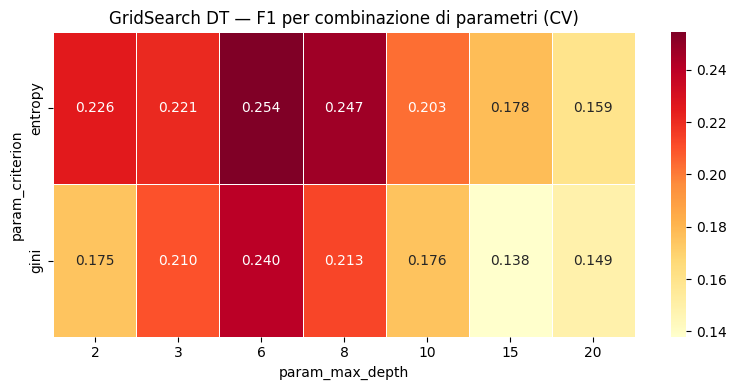

In [10]:
param_grid_dt = {
    'criterion': ['entropy', 'gini'],
    'max_depth': [2, 3, 6, 8, 10, 15, 20, None]
}

gs_dt = GridSearchCV(
    DecisionTreeClassifier(class_weight='balanced', random_state=random_seed),
    param_grid_dt,
    cv=skf,
    scoring='f1',
    refit=True,
    n_jobs=-1
)
gs_dt.fit(X_train, y_train)

print(f"Migliori parametri DT: {gs_dt.best_params_}")
print(f"Miglior F1 (CV):       {gs_dt.best_score_:.4f}")

plot_gridsearch_heatmap(gs_dt,
    param_x='param_max_depth',
    param_y='param_criterion',
    title='GridSearch DT — F1 per combinazione di parametri (CV)')

best_dt = gs_dt.best_estimator_


#### 3.2 Valutazione modello DT

Il modello ottimale viene valutato sul test set sia nella versione continua che discretizzata.

In [11]:
# Continuo
dt_pred = best_dt.predict(X_test)
dt_prob = best_dt.predict_proba(X_test)[:, 1]
res_dt  = evaluate(y_test, dt_pred, dt_prob, 'Decision Tree (continuo)')

# Discretizzato
best_dt_d = DecisionTreeClassifier(
    criterion=gs_dt.best_params_['criterion'],
    max_depth=gs_dt.best_params_['max_depth'],
    class_weight='balanced', random_state=random_seed)
best_dt_d.fit(X_train_d, y_train_d)
dt_d_pred = best_dt_d.predict(X_test_d)
dt_d_prob = best_dt_d.predict_proba(X_test_d)[:, 1]
res_dt_d  = evaluate(y_test_d, dt_d_pred, dt_d_prob, 'Decision Tree (discr.)')


=== Decision Tree (continuo) ===
              precision    recall  f1-score   support

     Rimasto       0.86      0.38      0.52       127
      Uscito       0.16      0.65      0.26        23

    accuracy                           0.42       150
   macro avg       0.51      0.52      0.39       150
weighted avg       0.75      0.42      0.48       150

Confusion Matrix:
                Pred: Rimasto  Pred: Uscito
Reale: Rimasto             48            79
Reale: Uscito               8            15

=== Decision Tree (discr.) ===
              precision    recall  f1-score   support

     Rimasto       0.82      0.52      0.64       127
      Uscito       0.13      0.39      0.19        23

    accuracy                           0.50       150
   macro avg       0.48      0.46      0.42       150
weighted avg       0.72      0.50      0.57       150

Confusion Matrix:
                Pred: Rimasto  Pred: Uscito
Reale: Rimasto             66            61
Reale: Uscito            

#### 3.3 Feature importance

Visualizzazione dell'albero (troncato ai primi 4 livelli) e delle feature importance basate sulla riduzione media di impurità.

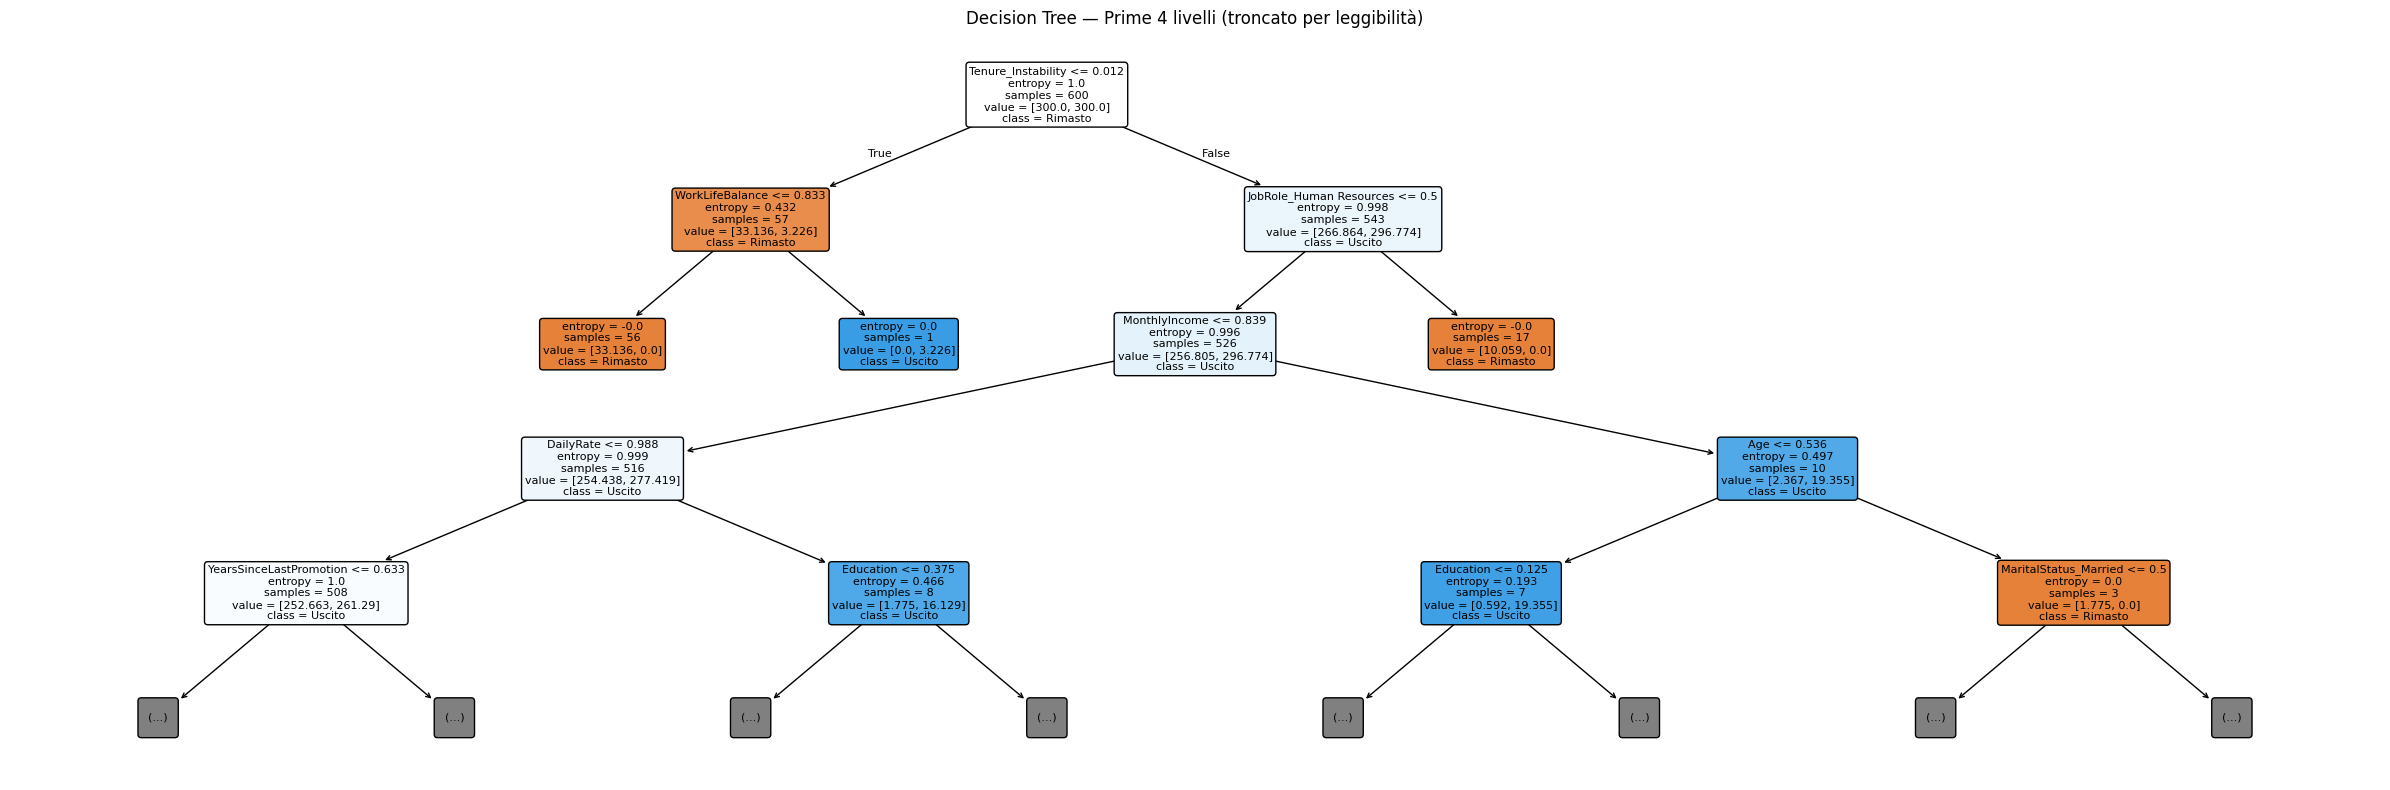

|--- Tenure_Instability <= 0.01
|   |--- WorkLifeBalance <= 0.83
|   |   |--- class: 0
|   |--- WorkLifeBalance >  0.83
|   |   |--- class: 1
|--- Tenure_Instability >  0.01
|   |--- JobRole_Human Resources <= 0.50
|   |   |--- MonthlyIncome <= 0.84
|   |   |   |--- DailyRate <= 0.99
|   |   |   |   |--- YearsSinceLastPromotion <= 0.63
|   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |--- YearsSinceLastPromotion >  0.63
|   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- DailyRate >  0.99
|   |   |   |   |--- Education <= 0.38
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- Education >  0.38
|   |   |   |   |   |--- truncated branch of depth 2
|   |   |--- MonthlyIncome >  0.84
|   |   |   |--- Age <= 0.54
|   |   |   |   |--- Education <= 0.12
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- Education >  0.12
|   |   |   |   |   |--- class: 1
|   |   |   |--- Age >  0.54
|   |   |   |   |--- MaritalStatus_Married <= 0.50
|   |   |   |

In [12]:
plt.figure(figsize=(24, 8))
plot_tree(best_dt, feature_names=X_train.columns, class_names=['Rimasto', 'Uscito'],
          filled=True, max_depth=4, fontsize=8, impurity=True, rounded=True)
plt.title('Decision Tree — Prime 4 livelli (troncato per leggibilità)')
plt.tight_layout()
plt.show()

print(export_text(best_dt, feature_names=list(X_train.columns), max_depth=4))


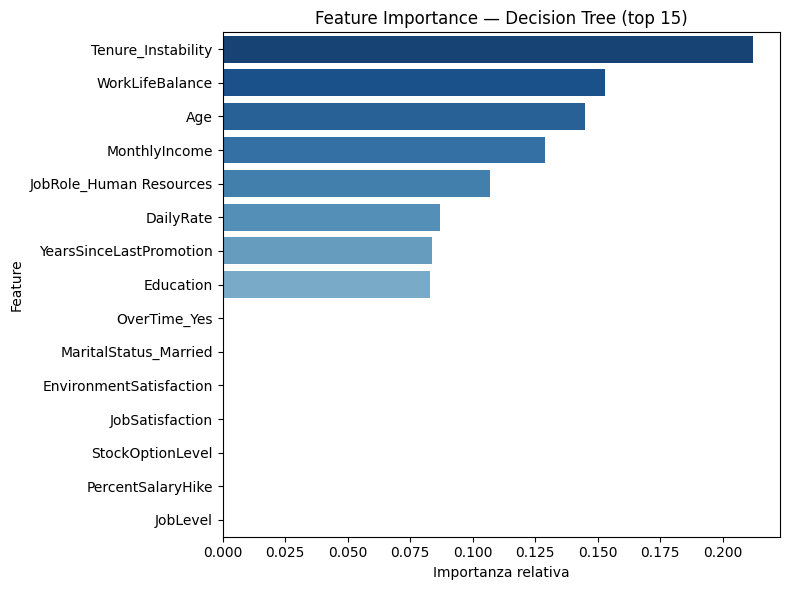

Top 10 feature più importanti (Decision Tree):
                Feature  Importance
     Tenure_Instability      0.2122
        WorkLifeBalance      0.1530
                    Age      0.1450
          MonthlyIncome      0.1291
JobRole_Human Resources      0.1071
              DailyRate      0.0871
YearsSinceLastPromotion      0.0836
              Education      0.0828
           OverTime_Yes      0.0000
  MaritalStatus_Married      0.0000


In [13]:
dt_importances = pd.DataFrame({
    'Feature':    X_train.columns,
    'Importance': best_dt.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(data=dt_importances.head(15), x='Importance', y='Feature',
            hue='Feature', palette='Blues_r', legend=False)
plt.title('Feature Importance — Decision Tree (top 15)')
plt.xlabel('Importanza relativa')
plt.tight_layout()
plt.show()

print('Top 10 feature più importanti (Decision Tree):')
print(dt_importances.head(10).round(4).to_string(index=False))


## 4. Random Forest

Il Random Forest è un ensemble di T alberi decisionali addestrati su campioni bootstrap (bagging), con selezione casuale di √p feature ad ogni split. La predizione finale è il voto di maggioranza:

$$\hat{y} = \text{mode}\{h_1(\mathbf{x}), h_2(\mathbf{x}), \ldots, h_T(\mathbf{x})\}$$

Rispetto al singolo DT, riduce la varianza mantenendo bias basso ed è robusto a rumore e outlier. Il trade-off è la minore interpretabilità.


#### 4.1 Tuning dei parametri del RF

**GridSearch**: `n_estimators` ∈ {10,15,20,25,50,100,150} × `max_depth` ∈ {1,2,3,4,5,10,20,None}

Migliori parametri RF: {'max_depth': 1, 'n_estimators': 25}
Miglior F1 (CV):       0.2370


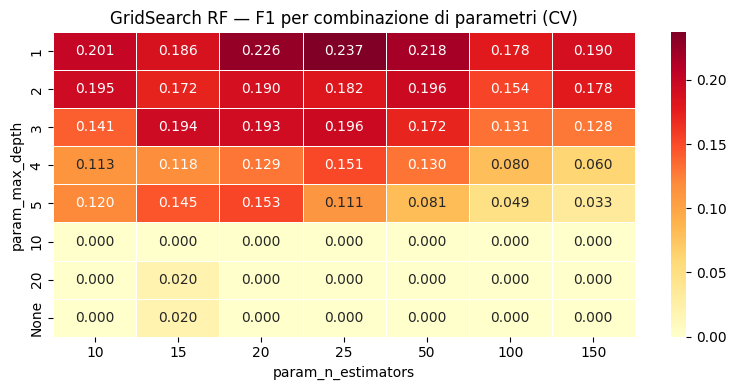

In [14]:
param_grid_rf = {
    'n_estimators': [10, 15, 20, 25, 50, 100, 150],
    'max_depth':    [1, 2, 3, 4, 5, 10, 20, None]
}

gs_rf = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=random_seed, n_jobs=-1),
    param_grid_rf,
    cv=skf,
    scoring='f1',
    refit=True,
    n_jobs=-1,
)
gs_rf.fit(X_train, y_train)

print(f"Migliori parametri RF: {gs_rf.best_params_}")
print(f"Miglior F1 (CV):       {gs_rf.best_score_:.4f}")

plot_gridsearch_heatmap(gs_rf,
    param_x='param_n_estimators',
    param_y='param_max_depth',
    title='GridSearch RF — F1 per combinazione di parametri (CV)')

best_rf = gs_rf.best_estimator_


#### 4.2 Valutazione modello RF

In [15]:
# Continuo
rf_pred = best_rf.predict(X_test)
rf_prob = best_rf.predict_proba(X_test)[:, 1]
res_rf  = evaluate(y_test, rf_pred, rf_prob, 'Random Forest (continuo)')

# Discretizzato
best_rf_d = RandomForestClassifier(
    n_estimators=gs_rf.best_params_['n_estimators'],
    max_depth=gs_rf.best_params_['max_depth'],
    class_weight='balanced', random_state=random_seed, n_jobs=-1)
best_rf_d.fit(X_train_d, y_train_d)
rf_d_pred = best_rf_d.predict(X_test_d)
rf_d_prob = best_rf_d.predict_proba(X_test_d)[:, 1]
res_rf_d  = evaluate(y_test_d, rf_d_pred, rf_d_prob, 'Random Forest (discr.)')


=== Random Forest (continuo) ===
              precision    recall  f1-score   support

     Rimasto       0.86      0.52      0.65       127
      Uscito       0.16      0.52      0.25        23

    accuracy                           0.52       150
   macro avg       0.51      0.52      0.45       150
weighted avg       0.75      0.52      0.59       150

Confusion Matrix:
                Pred: Rimasto  Pred: Uscito
Reale: Rimasto             66            61
Reale: Uscito              11            12

=== Random Forest (discr.) ===
              precision    recall  f1-score   support

     Rimasto       0.84      0.48      0.61       127
      Uscito       0.14      0.48      0.22        23

    accuracy                           0.48       150
   macro avg       0.49      0.48      0.41       150
weighted avg       0.73      0.48      0.55       150

Confusion Matrix:
                Pred: Rimasto  Pred: Uscito
Reale: Rimasto             61            66
Reale: Uscito            

#### 4.3 Feature importance

La feature importance del RF misura la riduzione media di impurità pesata sui nodi in cui ogni variabile viene usata, mediata su tutti gli alberi.

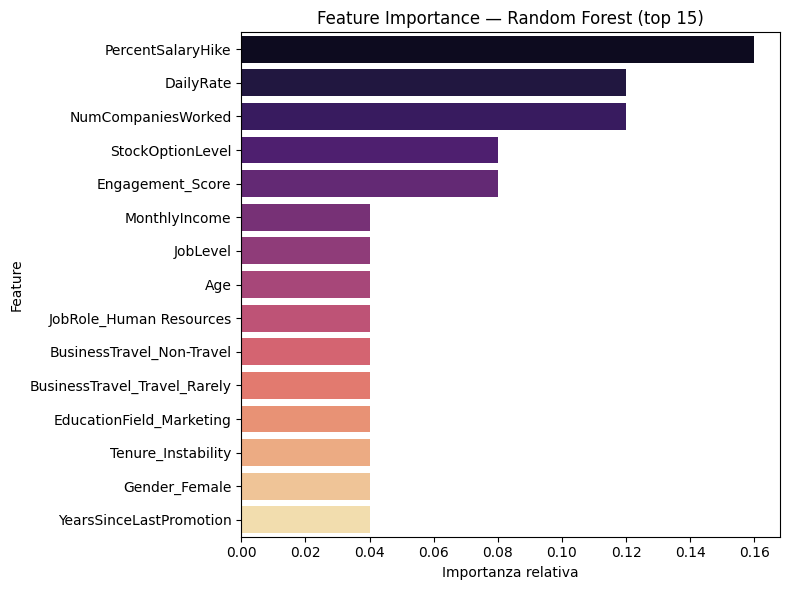

Top 10 feature più importanti:
                      Feature  Importance
6           PercentSalaryHike        0.16
5                   DailyRate        0.12
17         NumCompaniesWorked        0.12
7            StockOptionLevel        0.08
19           Engagement_Score        0.08
4               MonthlyIncome        0.04
3                    JobLevel        0.04
0                         Age        0.04
35    JobRole_Human Resources        0.04
43  BusinessTravel_Non-Travel        0.04


In [16]:
rf_importances = pd.DataFrame({
    'Feature':    X_train.columns,
    'Importance': best_rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(data=rf_importances.head(15), x='Importance', y='Feature',
            hue='Feature', palette='magma', legend=False)
plt.title('Feature Importance — Random Forest (top 15)')
plt.xlabel('Importanza relativa')
plt.tight_layout()
plt.show()

print('Top 10 feature più importanti:')
print(rf_importances.head(10).round(4).to_string())


## 5. k-Nearest Neighbor (k-NN)

Il k-NN classifica ogni istanza in base alla **maggioranza delle etichette** dei k vicini più prossimi nello spazio delle feature.
Non costruisce un modello esplicito (lazy learner): il training è istantaneo ma la predizione richiede il calcolo delle distanze sull'intero dataset.
La normalizzazione delle feature è fondamentale per questo algoritmo.
**Nota sullo sbilanciamento:** `KNeighborsClassifier` non supporta `class_weight` né `sample_weight` in fase di fit. Il limite viene accettato: la GridSearch con scoring `f1` favorisce comunque configurazioni che bilanciano precision e recall sulla classe minoritaria, mitigando parzialmente l'effetto dello sbilanciamento.


#### 5.1 Tuning dei parametri del k-NN

**GridSearch**: `n_neighbors` ∈ {1,2,3,5,7,9,11,15,21,31} × `metric` ∈ {euclidean, manhattan}

Best params: {'metric': 'euclidean', 'n_neighbors': 1}
Best F1 (CV): 0.2248


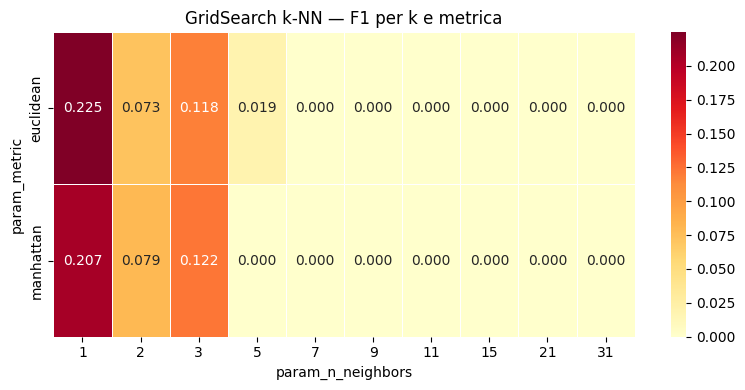

In [17]:
param_grid_knn = {
    'n_neighbors': [1, 2, 3, 5, 7, 9, 11, 15, 21, 31],
    'metric': ['euclidean', 'manhattan']
}

gs_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    cv=skf,
    scoring='f1',
    n_jobs=-1
)
gs_knn.fit(X_train, y_train)
best_knn = gs_knn.best_estimator_
print('Best params:', gs_knn.best_params_)
print('Best F1 (CV):', round(gs_knn.best_score_, 4))

plot_gridsearch_heatmap(gs_knn,
    param_x='param_n_neighbors',
    param_y='param_metric',
    title='GridSearch k-NN — F1 per k e metrica')


#### 5.2 Valutazione modello k-NN

In [18]:
# Continuo
knn_pred = best_knn.predict(X_test)
knn_prob = best_knn.predict_proba(X_test)[:, 1]
res_knn  = evaluate(y_test, knn_pred, knn_prob, 'k-NN (continuo)')

# Discretizzato
best_knn_d = KNeighborsClassifier(
    n_neighbors=gs_knn.best_params_['n_neighbors'],
    metric=gs_knn.best_params_['metric'])
best_knn_d.fit(X_train_d, y_train_d)
knn_d_pred = best_knn_d.predict(X_test_d)
knn_d_prob = best_knn_d.predict_proba(X_test_d)[:, 1]
res_knn_d  = evaluate(y_test_d, knn_d_pred, knn_d_prob, 'k-NN (discr.)')


=== k-NN (continuo) ===
              precision    recall  f1-score   support

     Rimasto       0.83      0.85      0.84       127
      Uscito       0.05      0.04      0.05        23

    accuracy                           0.73       150
   macro avg       0.44      0.45      0.44       150
weighted avg       0.71      0.73      0.72       150

Confusion Matrix:
                Pred: Rimasto  Pred: Uscito
Reale: Rimasto            108            19
Reale: Uscito              22             1

=== k-NN (discr.) ===
              precision    recall  f1-score   support

     Rimasto       0.84      0.85      0.84       127
      Uscito       0.10      0.09      0.09        23

    accuracy                           0.73       150
   macro avg       0.47      0.47      0.47       150
weighted avg       0.72      0.73      0.73       150

Confusion Matrix:
                Pred: Rimasto  Pred: Uscito
Reale: Rimasto            108            19
Reale: Uscito              21             2

#### 5.3 Feature importance

Il k-NN non ha feature importance nativa. Si usa la **Permutation Importance**: misura il calo di F1 quando ogni feature viene rimescolata casualmente sul test set — più cala, più la feature è rilevante.

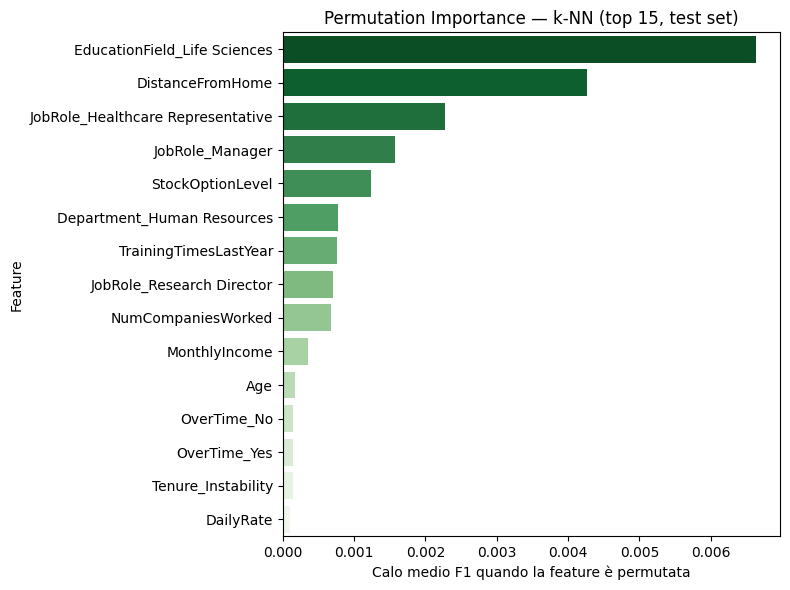

Top 10 feature più importanti (k-NN, permutation importance):
                          Feature  Importance    Std
     EducationField_Life Sciences      0.0066 0.0289
                 DistanceFromHome      0.0043 0.0114
JobRole_Healthcare Representative      0.0023 0.0118
                  JobRole_Manager      0.0016 0.0011
                 StockOptionLevel      0.0012 0.0011
       Department_Human Resources      0.0008 0.0005
            TrainingTimesLastYear      0.0008 0.0010
        JobRole_Research Director      0.0007 0.0007
               NumCompaniesWorked      0.0007 0.0013
                    MonthlyIncome      0.0003 0.0006


In [19]:
perm_knn = permutation_importance(
    best_knn, X_test, y_test,
    scoring='f1', n_repeats=15, random_state=random_seed, n_jobs=-1
)
knn_importances = pd.DataFrame({
    'Feature':    X_train.columns,
    'Importance': perm_knn.importances_mean,
    'Std':        perm_knn.importances_std
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(data=knn_importances.head(15), x='Importance', y='Feature',
            hue='Feature', palette='Greens_r', legend=False)
plt.title('Permutation Importance — k-NN (top 15, test set)')
plt.xlabel('Calo medio F1 quando la feature è permutata')
plt.tight_layout()
plt.show()

print('Top 10 feature più importanti (k-NN, permutation importance):')
print(knn_importances.head(10).round(4).to_string(index=False))


## 6. Naïve Bayes Gaussiano

Il Naïve Bayes applica il teorema di Bayes assumendo **indipendenza condizionale** tra le feature dato la classe.
Per attributi continui si assume distribuzione **gaussiana**: $P(x_i|C) \sim \mathcal{N}(\mu_C, \sigma^2_C)$.
Il parametro `var_smoothing` aggiunge una piccola costante ε alla varianza stimata per stabilità numerica.


#### 6.1 Tuning dei parametri del Naïve Bayes

**GridSearch**: `var_smoothing` ∈ [10⁻¹², 1] (13 valori log-uniformi)

Best params: {'var_smoothing': np.float64(1e-05)}
Best F1 (CV): 0.2767


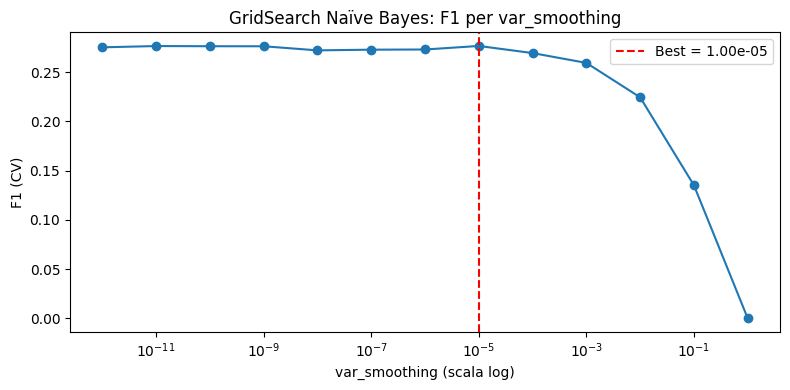

In [20]:
param_grid_nb = {
    'var_smoothing': np.logspace(-12, 0, 13)
}

gs_nb = GridSearchCV(
    GaussianNB(),
    param_grid_nb,
    cv=skf,
    scoring='f1',
    n_jobs=-1
)
gs_nb.fit(X_train, y_train)
best_nb = gs_nb.best_estimator_
print('Best params:', gs_nb.best_params_)
print('Best F1 (CV):', round(gs_nb.best_score_, 4))

nb_cv_df = pd.DataFrame(gs_nb.cv_results_).sort_values('param_var_smoothing')
fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(nb_cv_df['param_var_smoothing'].astype(float),
            nb_cv_df['mean_test_score'], marker='o')
ax.axvline(best_nb.var_smoothing, color='red', linestyle='--',
           label=f'Best = {best_nb.var_smoothing:.2e}')
ax.set_xlabel('var_smoothing (scala log)')
ax.set_ylabel('F1 (CV)')
ax.set_title('GridSearch Naïve Bayes: F1 per var_smoothing')
ax.legend()
plt.tight_layout()
plt.show()


#### 6.2 Valutazione Naïve Bayes

In [21]:
# Continuo
nb_pred = best_nb.predict(X_test)
nb_prob = best_nb.predict_proba(X_test)[:, 1]
res_nb  = evaluate(y_test, nb_pred, nb_prob, 'Naive Bayes (continuo)')

# Discretizzato
best_nb_d = GaussianNB(var_smoothing=gs_nb.best_params_['var_smoothing'])
best_nb_d.fit(X_train_d, y_train_d)
nb_d_pred = best_nb_d.predict(X_test_d)
nb_d_prob = best_nb_d.predict_proba(X_test_d)[:, 1]
res_nb_d  = evaluate(y_test_d, nb_d_pred, nb_d_prob, 'Naive Bayes (discr.)')


=== Naive Bayes (continuo) ===
              precision    recall  f1-score   support

     Rimasto       0.89      0.13      0.23       127
      Uscito       0.16      0.91      0.27        23

    accuracy                           0.25       150
   macro avg       0.53      0.52      0.25       150
weighted avg       0.78      0.25      0.24       150

Confusion Matrix:
                Pred: Rimasto  Pred: Uscito
Reale: Rimasto             17           110
Reale: Uscito               2            21

=== Naive Bayes (discr.) ===
              precision    recall  f1-score   support

     Rimasto       0.84      0.13      0.22       127
      Uscito       0.15      0.87      0.26        23

    accuracy                           0.24       150
   macro avg       0.50      0.50      0.24       150
weighted avg       0.74      0.24      0.23       150

Confusion Matrix:
                Pred: Rimasto  Pred: Uscito
Reale: Rimasto             16           111
Reale: Uscito               3

#### 6.3 Feature importance

Il Naïve Bayes non ha una feature importance diretta. Si usa il **Cohen's d** normalizzato: la distanza tra le medie delle due classi divisa per la deviazione standard pooled.
Un valore alto indica che la feature separa bene le distribuzioni delle due classi.


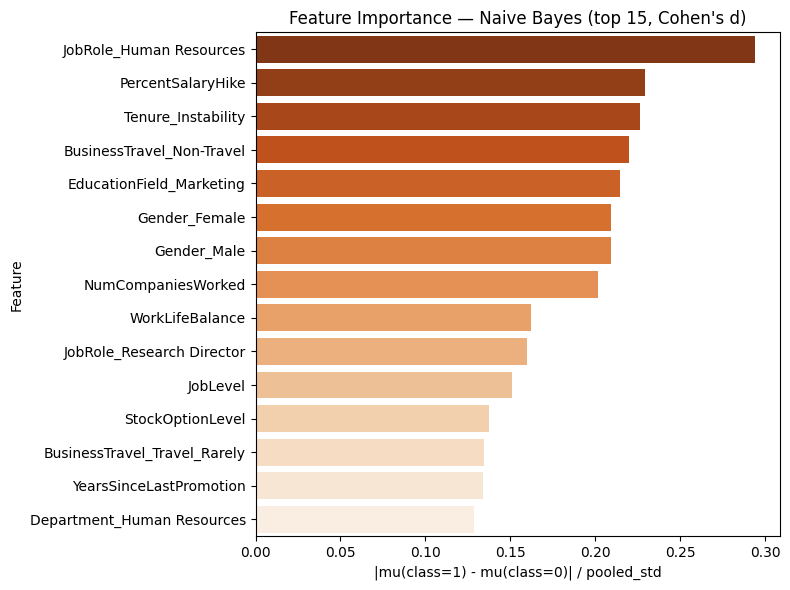

Top 10 feature più discriminanti (Naive Bayes):
                  Feature  Importance
  JobRole_Human Resources      0.2940
        PercentSalaryHike      0.2293
       Tenure_Instability      0.2263
BusinessTravel_Non-Travel      0.2196
 EducationField_Marketing      0.2144
            Gender_Female      0.2091
              Gender_Male      0.2091
       NumCompaniesWorked      0.2013
          WorkLifeBalance      0.1623
JobRole_Research Director      0.1595


In [22]:
nb_diff       = np.abs(best_nb.theta_[1] - best_nb.theta_[0])
nb_pooled_std = np.sqrt((best_nb.var_[0] + best_nb.var_[1]) / 2)
nb_score      = np.where(nb_pooled_std > 0, nb_diff / nb_pooled_std, 0)

nb_importances = pd.DataFrame({
    'Feature':    X_train.columns,
    'Importance': nb_score
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(data=nb_importances.head(15), x='Importance', y='Feature',
            hue='Feature', palette='Oranges_r', legend=False)
plt.title("Feature Importance — Naive Bayes (top 15, Cohen's d)")
plt.xlabel("|mu(class=1) - mu(class=0)| / pooled_std")
plt.tight_layout()
plt.show()

print('Top 10 feature più discriminanti (Naive Bayes):')
print(nb_importances.head(10).round(4).to_string(index=False))


## 7. Support Vector Machine (SVM)

La SVM trova l'iperpiano che massimizza il **margine** tra le due classi nello spazio delle feature (o in uno spazio trasformato tramite kernel).
Il parametro `C` controlla il trade-off tra margine ampio e penalizzazione degli errori di classificazione.
Il kernel `rbf` (Radial Basis Function) permette di separare classi non linearmente separabili nello spazio originale.
`probability=True` abilita la stima delle probabilità tramite Platt scaling, necessaria per il calcolo dell'AUC.


#### 7.1 Tuning dei parametri della SVM

**GridSearch**: `C` ∈ {0.01, 0.1, 1, 10, 100} × `kernel` ∈ {linear, rbf}

Best params: {'C': 0.01, 'kernel': 'linear'}
Best F1 (CV): 0.2142


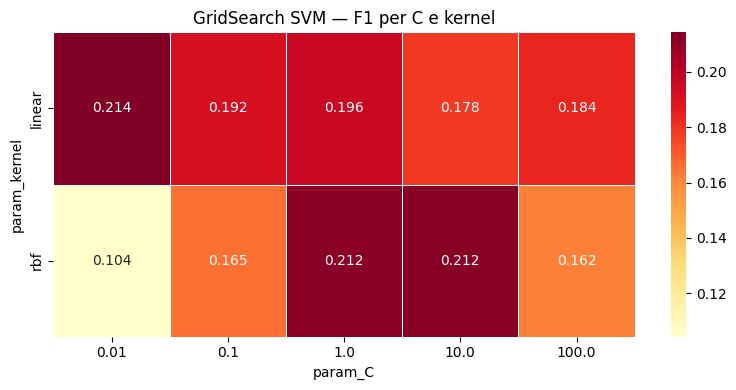

In [23]:
param_grid_svm = {
    'C':      [0.01, 0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf']
}

gs_svm = GridSearchCV(
    SVC(class_weight='balanced', probability=True, random_state=random_seed),
    param_grid_svm,
    cv=skf,
    scoring='f1',
    n_jobs=-1
)
gs_svm.fit(X_train, y_train)
best_svm = gs_svm.best_estimator_
print('Best params:', gs_svm.best_params_)
print('Best F1 (CV):', round(gs_svm.best_score_, 4))

plot_gridsearch_heatmap(gs_svm,
    param_x='param_C',
    param_y='param_kernel',
    title='GridSearch SVM — F1 per C e kernel')


#### 7.2 Valutazione modello SVM

In [24]:
# Continuo
svm_pred = best_svm.predict(X_test)
svm_prob = best_svm.predict_proba(X_test)[:, 1]
res_svm  = evaluate(y_test, svm_pred, svm_prob, 'SVM (continuo)')

# Discretizzato
best_svm_d = SVC(
    C=gs_svm.best_params_['C'],
    kernel=gs_svm.best_params_['kernel'],
    class_weight='balanced', probability=True, random_state=random_seed)
best_svm_d.fit(X_train_d, y_train_d)
svm_d_pred = best_svm_d.predict(X_test_d)
svm_d_prob = best_svm_d.predict_proba(X_test_d)[:, 1]
res_svm_d  = evaluate(y_test_d, svm_d_pred, svm_d_prob, 'SVM (discr.)')


=== SVM (continuo) ===
              precision    recall  f1-score   support

     Rimasto       0.82      0.58      0.68       127
      Uscito       0.12      0.30      0.17        23

    accuracy                           0.54       150
   macro avg       0.47      0.44      0.43       150
weighted avg       0.71      0.54      0.60       150

Confusion Matrix:
                Pred: Rimasto  Pred: Uscito
Reale: Rimasto             74            53
Reale: Uscito              16             7

=== SVM (discr.) ===
              precision    recall  f1-score   support

     Rimasto       0.82      0.65      0.72       127
      Uscito       0.10      0.22      0.14        23

    accuracy                           0.58       150
   macro avg       0.46      0.43      0.43       150
weighted avg       0.71      0.58      0.63       150

Confusion Matrix:
                Pred: Rimasto  Pred: Uscito
Reale: Rimasto             82            45
Reale: Uscito              18             5



#### 7.3 Feature importance

La SVM non ha una feature importance diretta (specialmente con kernel non lineare).
Si usa la **Permutation Importance** sul test set.


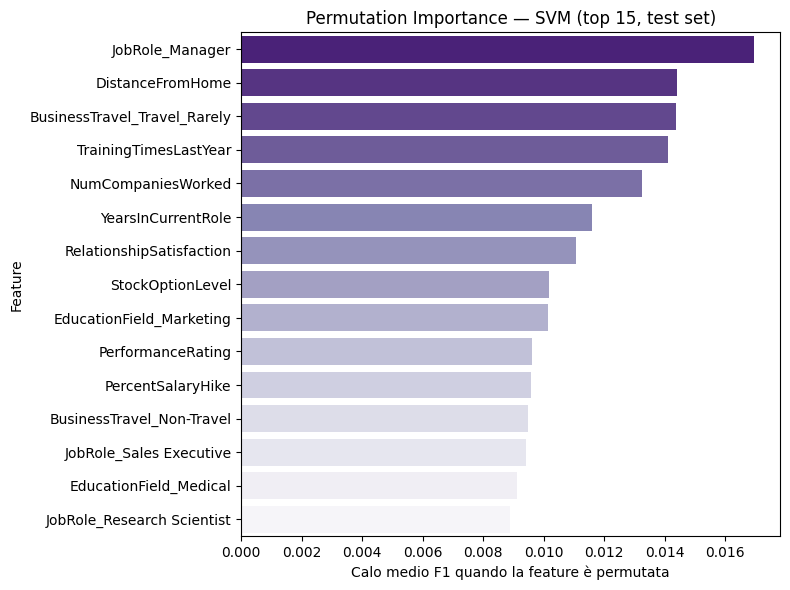

Top 10 feature più importanti (SVM, permutation importance):
                     Feature  Importance    Std
             JobRole_Manager      0.0170 0.0136
            DistanceFromHome      0.0144 0.0102
BusinessTravel_Travel_Rarely      0.0144 0.0127
       TrainingTimesLastYear      0.0141 0.0112
          NumCompaniesWorked      0.0132 0.0088
          YearsInCurrentRole      0.0116 0.0118
    RelationshipSatisfaction      0.0110 0.0104
            StockOptionLevel      0.0102 0.0144
    EducationField_Marketing      0.0101 0.0190
           PerformanceRating      0.0096 0.0103


In [25]:
perm_svm = permutation_importance(
    best_svm, X_test, y_test,
    scoring='f1', n_repeats=15, random_state=random_seed, n_jobs=-1
)
svm_importances = pd.DataFrame({
    'Feature':    X_train.columns,
    'Importance': perm_svm.importances_mean,
    'Std':        perm_svm.importances_std
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(data=svm_importances.head(15), x='Importance', y='Feature',
            hue='Feature', palette='Purples_r', legend=False)
plt.title('Permutation Importance — SVM (top 15, test set)')
plt.xlabel('Calo medio F1 quando la feature è permutata')
plt.tight_layout()
plt.show()

print('Top 10 feature più importanti (SVM, permutation importance):')
print(svm_importances.head(10).round(4).to_string(index=False))


## 8. Reti Neurali — MLP (Feed-Forward Neural Network)

Il **Multilayer Perceptron** è una FFNN con uno o più hidden layer. Ogni neurone applica una **funzione di attivazione** (ReLU o tanh) alla somma pesata degli input.
L'addestramento usa la **backpropagation**: l'errore viene propagato all'indietro e i pesi aggiornati tramite gradient descent.

**Parametri principali**:
- `hidden_layer_sizes`: architettura della rete (es. `(100, 50)` = 2 hidden layer).
- `activation`: funzione di attivazione (`relu` o `tanh`).
- `alpha`: regolarizzazione L2 sui pesi.


#### 8.1 Tuning parametri MLP

**GridSearch**: `hidden_layer_sizes` ∈ {(50,),(100,),(50,50),(100,50)} × `activation` ∈ {relu, tanh} × `alpha` ∈ {0.0001, 0.001}

Best params: {'activation': 'tanh', 'alpha': 0.0001, 'hidden_layer_sizes': (100, 50)}
Best F1 (CV): 0.1732


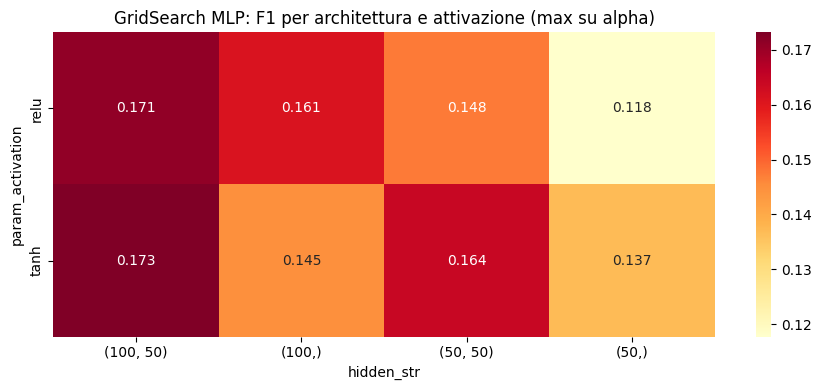

In [26]:
param_grid_mlp = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001]
}

gs_mlp = GridSearchCV(
    MLPClassifier(max_iter=2000, random_state=random_seed),
    param_grid_mlp,
    cv=skf,
    scoring='f1',
    n_jobs=-1
)
gs_mlp.fit(X_train, y_train)
best_mlp = gs_mlp.best_estimator_
print('Best params:', gs_mlp.best_params_)
print('Best F1 (CV):', round(gs_mlp.best_score_, 4))

cv_res_mlp = pd.DataFrame(gs_mlp.cv_results_)
cv_res_mlp['hidden_str'] = cv_res_mlp['param_hidden_layer_sizes'].astype(str)
pivot_mlp = cv_res_mlp.pivot_table(
    index='param_activation', columns='hidden_str',
    values='mean_test_score', aggfunc='max'
)
fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(pivot_mlp, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax)
ax.set_title('GridSearch MLP: F1 per architettura e attivazione (max su alpha)')
plt.tight_layout()
plt.show()


#### 8.2 Valutazione modello MLP

In [27]:
# Continuo
mlp_pred = best_mlp.predict(X_test)
mlp_prob = best_mlp.predict_proba(X_test)[:, 1]
res_mlp  = evaluate(y_test, mlp_pred, mlp_prob, 'MLP (continuo)')

# Discretizzato
best_mlp_d = MLPClassifier(
    hidden_layer_sizes=gs_mlp.best_params_['hidden_layer_sizes'],
    activation=gs_mlp.best_params_['activation'],
    alpha=gs_mlp.best_params_['alpha'],
    max_iter=2000,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15,
    random_state=random_seed
)
best_mlp_d.fit(X_train_d, y_train_d)
mlp_d_pred = best_mlp_d.predict(X_test_d)
mlp_d_prob = best_mlp_d.predict_proba(X_test_d)[:, 1]
res_mlp_d  = evaluate(y_test_d, mlp_d_pred, mlp_d_prob, 'MLP (discr.)')


=== MLP (continuo) ===
              precision    recall  f1-score   support

     Rimasto       0.85      0.87      0.86       127
      Uscito       0.16      0.13      0.14        23

    accuracy                           0.76       150
   macro avg       0.50      0.50      0.50       150
weighted avg       0.74      0.76      0.75       150

Confusion Matrix:
                Pred: Rimasto  Pred: Uscito
Reale: Rimasto            111            16
Reale: Uscito              20             3

=== MLP (discr.) ===
              precision    recall  f1-score   support

     Rimasto       0.85      1.00      0.92       127
      Uscito       0.00      0.00      0.00        23

    accuracy                           0.85       150
   macro avg       0.42      0.50      0.46       150
weighted avg       0.72      0.85      0.78       150

Confusion Matrix:
                Pred: Rimasto  Pred: Uscito
Reale: Rimasto            127             0
Reale: Uscito              23             0



c:\Users\criba\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\criba\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\criba\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

#### 8.3 Feature importance

Anche per l'MLP si usa la Permutation Importance, poiché i pesi della rete non sono direttamente interpretabili come rilevanza delle feature originali.

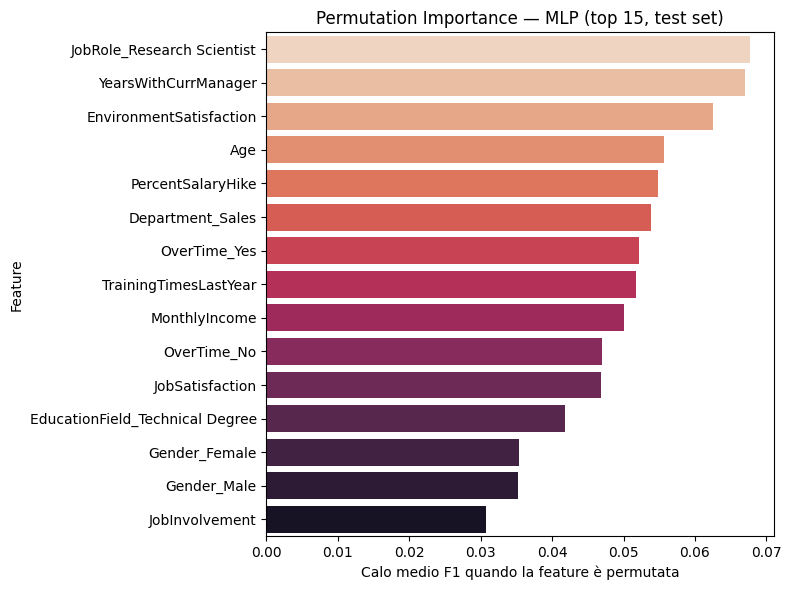

Top 10 feature più importanti (MLP, permutation importance):
                   Feature  Importance    Std
JobRole_Research Scientist      0.0677 0.0362
      YearsWithCurrManager      0.0670 0.0334
   EnvironmentSatisfaction      0.0625 0.0323
                       Age      0.0556 0.0332
         PercentSalaryHike      0.0548 0.0258
          Department_Sales      0.0539 0.0354
              OverTime_Yes      0.0522 0.0286
     TrainingTimesLastYear      0.0517 0.0283
             MonthlyIncome      0.0500 0.0260
               OverTime_No      0.0470 0.0300


In [28]:
perm_mlp = permutation_importance(
    best_mlp, X_test, y_test,
    scoring='f1', n_repeats=15, random_state=random_seed, n_jobs=-1
)
mlp_importances = pd.DataFrame({
    'Feature':    X_train.columns,
    'Importance': perm_mlp.importances_mean,
    'Std':        perm_mlp.importances_std
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(data=mlp_importances.head(15), x='Importance', y='Feature',
            hue='Feature', palette='rocket_r', legend=False)
plt.title('Permutation Importance — MLP (top 15, test set)')
plt.xlabel('Calo medio F1 quando la feature è permutata')
plt.tight_layout()
plt.show()

print('Top 10 feature più importanti (MLP, permutation importance):')
print(mlp_importances.head(10).round(4).to_string(index=False))



## 9. Analisi Comparativa

Confronto di tutti i modelli sulle metriche principali (Accuracy, Precision, Recall, F1, AUC) sia sul dataset continuo che discretizzato.
Le metriche più rilevanti per questo task HR sono **Recall** (quanti dipendenti a rischio vengono identificati) e **F1** (bilanciamento tra precision e recall sulla classe minoritaria).



=== Dati Continui ===
                          Accuracy  Precision  Recall      F1     AUC
Modello                                                              
Decision Tree (continuo)    0.4200     0.1596  0.6522  0.2564  0.5358
Random Forest (continuo)    0.5200     0.1644  0.5217  0.2500  0.5341
k-NN (continuo)             0.7267     0.0500  0.0435  0.0465  0.4469
Naive Bayes (continuo)      0.2533     0.1603  0.9130  0.2727  0.5248
SVM (continuo)              0.5400     0.1167  0.3043  0.1687  0.5875
MLP (continuo)              0.7600     0.1579  0.1304  0.1429  0.4653


C:\Users\criba\AppData\Local\Temp\ipykernel_9052\1214828784.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index, rotation=45, ha='right', fontsize=8)
C:\Users\criba\AppData\Local\Temp\ipykernel_9052\1214828784.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index, rotation=45, ha='right', fontsize=8)
C:\Users\criba\AppData\Local\Temp\ipykernel_9052\1214828784.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index, rotation=45, ha='right', fontsize=8)
C:\Users\criba\AppData\Local\Temp\ipykernel_9052\1214828784.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_x

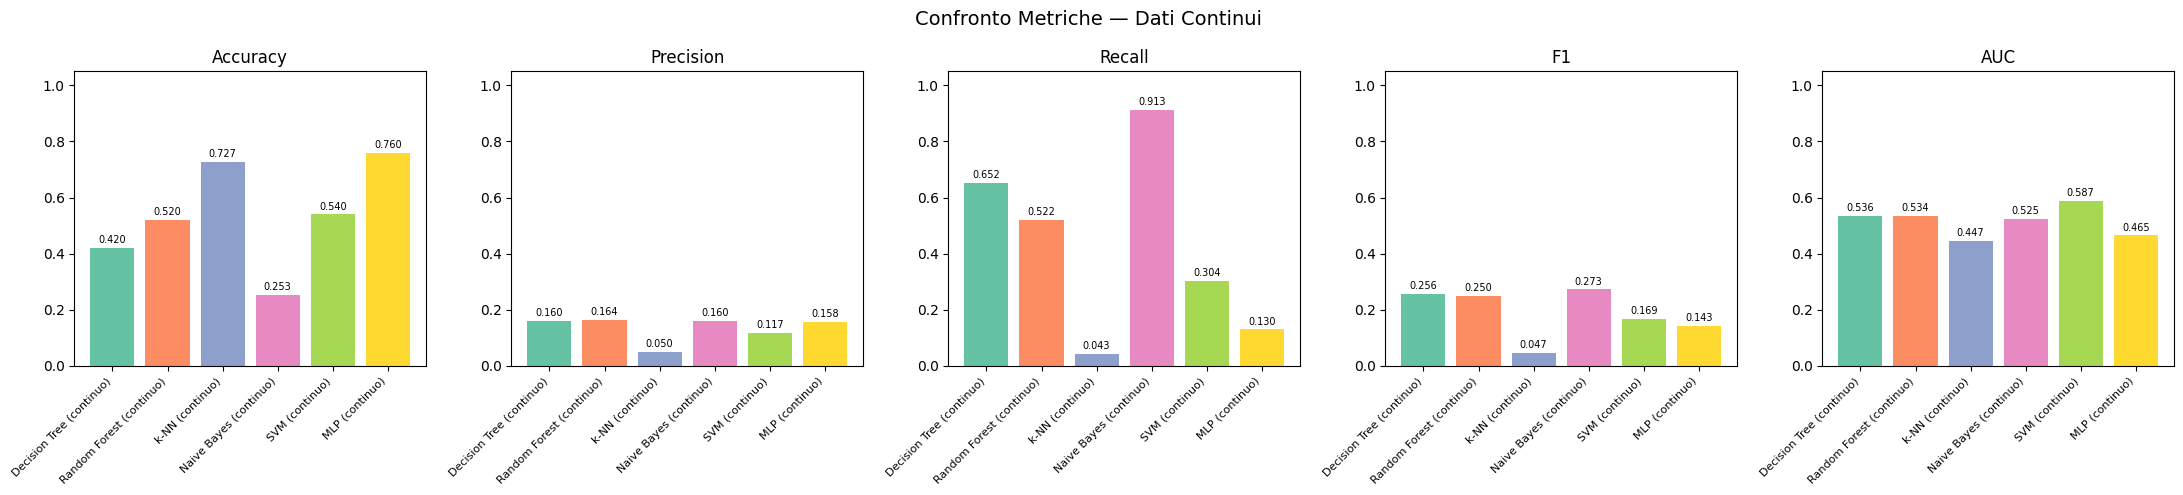


=== Dati Discretizzati ===
                        Accuracy  Precision  Recall      F1     AUC
Modello                                                            
Decision Tree (discr.)    0.5000     0.1286  0.3913  0.1935  0.4478
Random Forest (discr.)    0.4800     0.1429  0.4783  0.2200  0.4979
k-NN (discr.)             0.7333     0.0952  0.0870  0.0909  0.4687
Naive Bayes (discr.)      0.2400     0.1527  0.8696  0.2597  0.5159
SVM (discr.)              0.5800     0.1000  0.2174  0.1370  0.4204
MLP (discr.)              0.8467     0.0000  0.0000  0.0000  0.4574


C:\Users\criba\AppData\Local\Temp\ipykernel_9052\1214828784.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index, rotation=45, ha='right', fontsize=8)
C:\Users\criba\AppData\Local\Temp\ipykernel_9052\1214828784.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index, rotation=45, ha='right', fontsize=8)
C:\Users\criba\AppData\Local\Temp\ipykernel_9052\1214828784.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index, rotation=45, ha='right', fontsize=8)
C:\Users\criba\AppData\Local\Temp\ipykernel_9052\1214828784.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_x

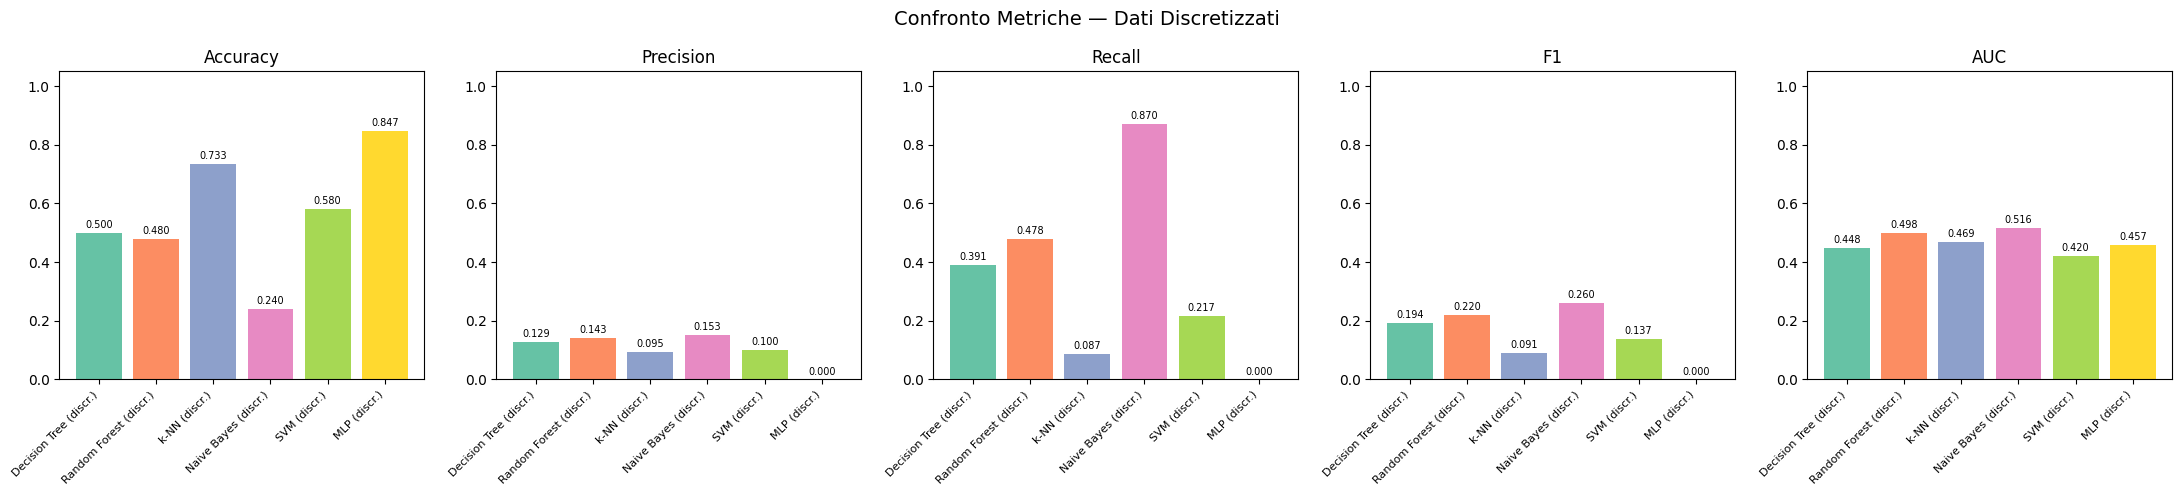

In [29]:
results_cont  = [res_dt, res_rf, res_knn, res_nb, res_svm, res_mlp]
results_discr = [res_dt_d, res_rf_d, res_knn_d, res_nb_d, res_svm_d, res_mlp_d]

def tabella_e_barplot(results, titolo):
    summary = pd.DataFrame([
        {k: v for k, v in r.items() if k not in ['y_pred', 'y_prob']}
        for r in results
    ]).set_index('Modello')
    print(f'\n=== {titolo} ===')
    print(summary.round(4).to_string())
    metriche = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
    palette  = sns.color_palette('Set2', len(results))
    fig, axes = plt.subplots(1, len(metriche), figsize=(22, 5))
    for ax, m in zip(axes, metriche):
        vals = summary[m]
        bars = ax.bar(vals.index, vals.values, color=palette)
        ax.set_title(m, fontsize=12)
        ax.set_ylim(0, 1.05)
        ax.set_xticklabels(vals.index, rotation=45, ha='right', fontsize=8)
        for bar, v in zip(bars, vals.values):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{v:.3f}', ha='center', va='bottom', fontsize=7)
    plt.suptitle(f'Confronto Metriche — {titolo}', fontsize=14)
    plt.tight_layout()
    plt.show()
    return summary

summary_cont  = tabella_e_barplot(results_cont,  'Dati Continui')
summary_discr = tabella_e_barplot(results_discr, 'Dati Discretizzati')


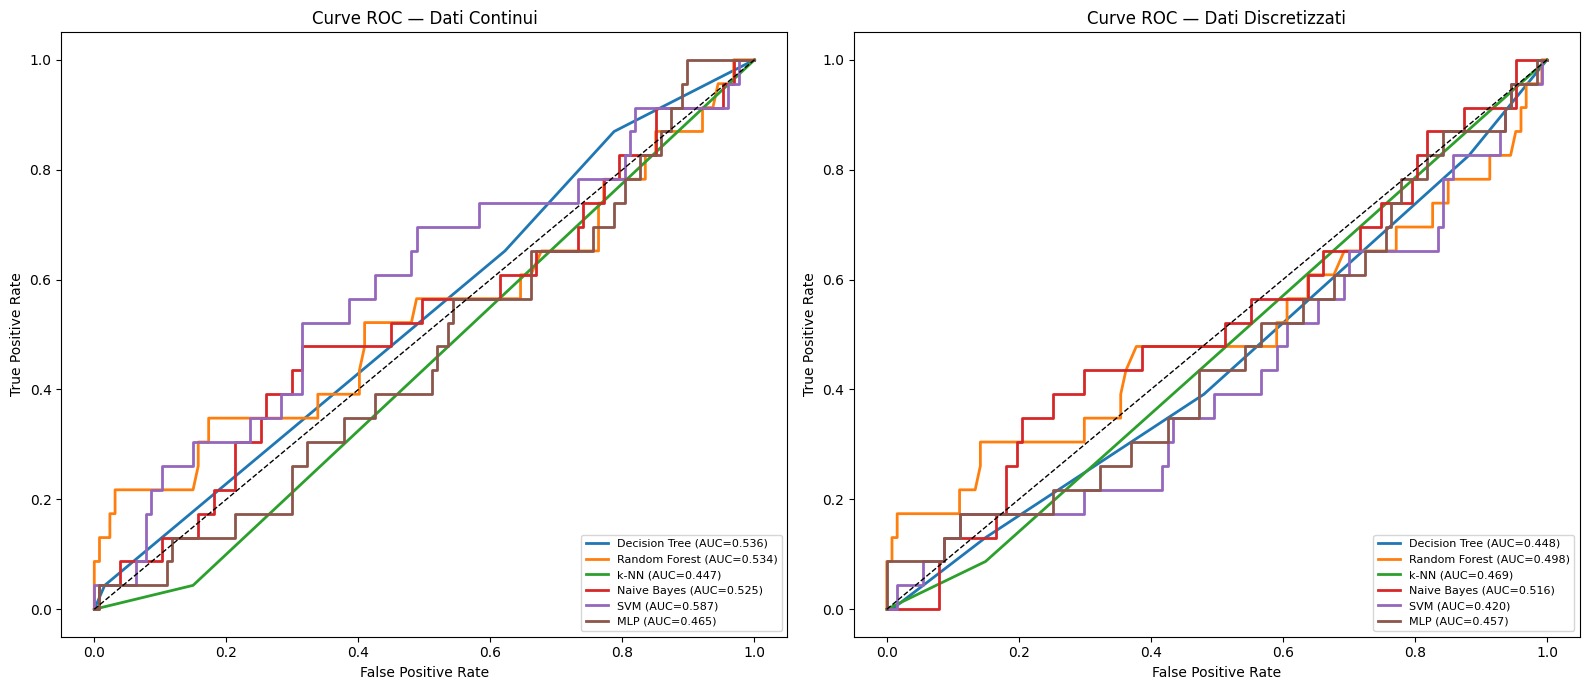

In [30]:
def plot_roc(results, y_true, titolo, ax):
    colors = sns.color_palette('tab10', len(results))
    for res, col in zip(results, colors):
        fpr, tpr, _ = metrics.roc_curve(y_true, res['y_prob'])
        label = res['Modello'].replace(' (continuo)', '').replace(' (discr.)', '')
        ax.plot(fpr, tpr, color=col, label=f"{label} (AUC={res['AUC']:.3f})", lw=2)
    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'Curve ROC — {titolo}')
    ax.legend(loc='lower right', fontsize=8)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
plot_roc(results_cont,  y_test,   'Dati Continui',      ax1)
plot_roc(results_discr, y_test_d, 'Dati Discretizzati', ax2)
plt.tight_layout()
plt.show()


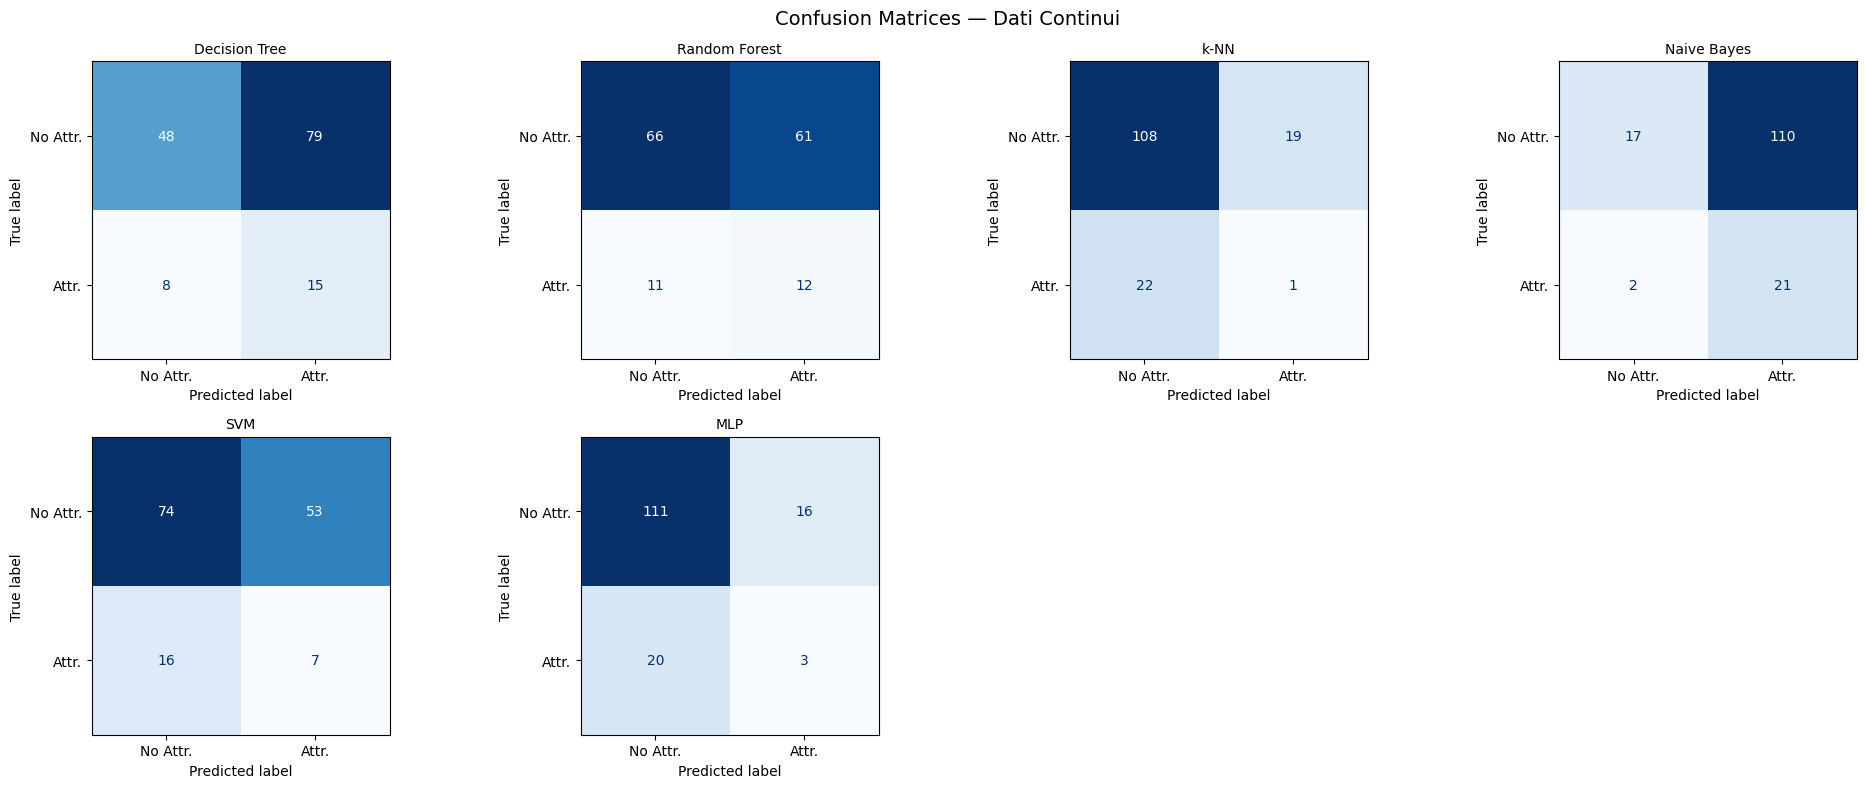

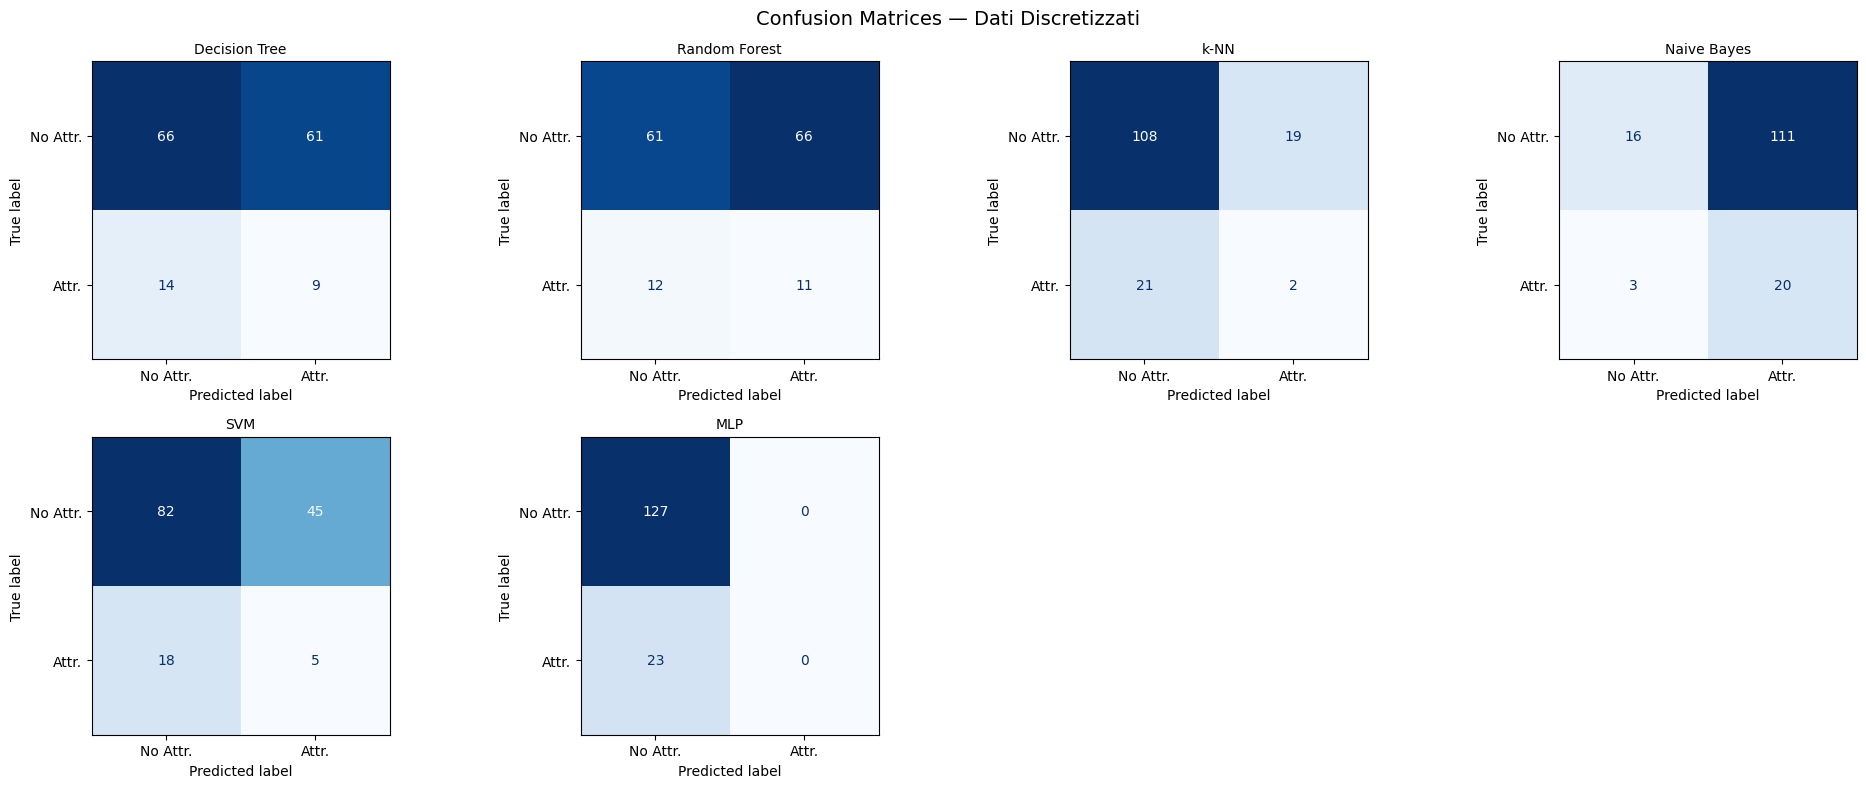

In [31]:
def plot_cm_grid(results, y_true, titolo):
    n    = len(results)
    cols = 4
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4))
    axes = axes.flatten()
    for i, res in enumerate(results):
        cm   = metrics.confusion_matrix(y_true, res['y_pred'])
        disp = metrics.ConfusionMatrixDisplay(cm, display_labels=['No Attr.', 'Attr.'])
        disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
        short = res['Modello'].replace(' (continuo)', '').replace(' (discr.)', '')
        axes[i].set_title(short, fontsize=10)
    for j in range(n, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle(f'Confusion Matrices — {titolo}', fontsize=14)
    plt.tight_layout()
    plt.show()

plot_cm_grid(results_cont,  y_test,   'Dati Continui')
plot_cm_grid(results_discr, y_test_d, 'Dati Discretizzati')


## 10. Studio delle metriche dei modelli per estrarre informazioni sulla feature selection
Script usato per feature selection in fase preprocessing

In [32]:
'''
from itertools import combinations

candidate_cols = ['Engagement_Score', 'Tenure_Instability', 'HourlyRate', 'DailyRate', 'OverTime', 'YearsSinceLastPromotion' ]

all_subsets = []
for r in range(len(candidate_cols) + 1):
    for combo in combinations(candidate_cols, r):
        all_subsets.append(list(combo))

print(f"Combinazioni da testare: {len(all_subsets)}\n")
print(f"{'Rimosse':<50} {'F1_DT':>6} {'F1_RF':>6} {'F1_kNN':>7} {'F1_NB':>6} {'F1_SVM':>7} {'F1_MLP':>7} {'N':>4}")
print("-" * 100)

results_ablation = []

for cols_removed in all_subsets:
    X_tr = X_train.drop(columns=cols_removed, errors='ignore')
    X_te = X_test.drop(columns=cols_removed, errors='ignore')

    scores = {}

    # DT
    clf = DecisionTreeClassifier(criterion=gs_dt.best_params_['criterion'],
        max_depth=gs_dt.best_params_['max_depth'],
        class_weight='balanced', random_state=random_seed)
    clf.fit(X_tr, y_train)
    scores['DT'] = f1_score(y_test, clf.predict(X_te), zero_division=0)

    # RF
    clf = RandomForestClassifier(n_estimators=gs_rf.best_params_['n_estimators'],
        max_depth=gs_rf.best_params_['max_depth'],
        class_weight='balanced', random_state=random_seed, n_jobs=-1)
    clf.fit(X_tr, y_train)
    scores['RF'] = f1_score(y_test, clf.predict(X_te), zero_division=0)

    # kNN
    clf = KNeighborsClassifier(n_neighbors=gs_knn.best_params_['n_neighbors'],
        metric=gs_knn.best_params_['metric'])
    clf.fit(X_tr, y_train)
    scores['kNN'] = f1_score(y_test, clf.predict(X_te), zero_division=0)

    # NB
    clf = GaussianNB(var_smoothing=gs_nb.best_params_['var_smoothing'])
    clf.fit(X_tr, y_train)
    scores['NB'] = f1_score(y_test, clf.predict(X_te), zero_division=0)

    # SVM
    clf = SVC(C=gs_svm.best_params_['C'], kernel=gs_svm.best_params_['kernel'],
        class_weight='balanced', probability=False, random_state=random_seed)
    clf.fit(X_tr, y_train)
    scores['SVM'] = f1_score(y_test, clf.predict(X_te), zero_division=0)

    # MLP
    clf = MLPClassifier(hidden_layer_sizes=gs_mlp.best_params_['hidden_layer_sizes'],
        activation=gs_mlp.best_params_['activation'],
        alpha=gs_mlp.best_params_['alpha'],
        max_iter=2000, random_state=random_seed)
    clf.fit(X_tr, y_train)
    scores['MLP'] = f1_score(y_test, clf.predict(X_te), zero_division=0)

    label = str(cols_removed) if cols_removed else '[] (nessuna rimossa)'
    print(f"{label:<50} {scores['DT']:>6.3f} {scores['RF']:>6.3f} {scores['kNN']:>7.3f} "
          f"{scores['NB']:>6.3f} {scores['SVM']:>7.3f} {scores['MLP']:>7.3f} {X_tr.shape[1]:>4}")

    results_ablation.append({'Rimosse': cols_removed, 'N_feat': X_tr.shape[1], **scores})

df_abl = pd.DataFrame(results_ablation)

print("\n" + "=" * 100)
for modello in ['DT', 'RF', 'kNN', 'NB', 'SVM', 'MLP']:
    col = modello
    best = df_abl.loc[df_abl[col].idxmax()]
    print(f"Miglior config per F1 {modello}: {best['Rimosse']}  →  F1={best[col]:.4f}")
'''


'\nfrom itertools import combinations\n\ncandidate_cols = [\'Engagement_Score\', \'Tenure_Instability\', \'HourlyRate\', \'DailyRate\', \'OverTime\', \'YearsSinceLastPromotion\' ]\n\nall_subsets = []\nfor r in range(len(candidate_cols) + 1):\n    for combo in combinations(candidate_cols, r):\n        all_subsets.append(list(combo))\n\nprint(f"Combinazioni da testare: {len(all_subsets)}\n")\nprint(f"{\'Rimosse\':<50} {\'F1_DT\':>6} {\'F1_RF\':>6} {\'F1_kNN\':>7} {\'F1_NB\':>6} {\'F1_SVM\':>7} {\'F1_MLP\':>7} {\'N\':>4}")\nprint("-" * 100)\n\nresults_ablation = []\n\nfor cols_removed in all_subsets:\n    X_tr = X_train.drop(columns=cols_removed, errors=\'ignore\')\n    X_te = X_test.drop(columns=cols_removed, errors=\'ignore\')\n\n    scores = {}\n\n    # DT\n    clf = DecisionTreeClassifier(criterion=gs_dt.best_params_[\'criterion\'],\n        max_depth=gs_dt.best_params_[\'max_depth\'],\n        class_weight=\'balanced\', random_state=random_seed)\n    clf.fit(X_tr, y_train)\n    score

### Esportazioni immagini 

In [33]:
import os
import matplotlib
import matplotlib.pyplot as plt

img_dir = os.path.join('immagini_dafile_classificazione')
os.makedirs(img_dir, exist_ok=True)

# Mappa: nome file → funzione che genera la figura
def save_fig(fig, name):
    fig.savefig(os.path.join(img_dir, name), dpi=150, bbox_inches='tight')
    plt.close(fig)

# ── GridSearch heatmaps ───────────────────────────────────────────────────────
for gs, nome in [(gs_dt, 'DT'), (gs_rf, 'RF'), (gs_knn, 'kNN'), (gs_svm, 'SVM')]:
    cv_res = pd.DataFrame(gs.cv_results_)
    if nome == 'DT':
        pivot = cv_res.pivot_table('mean_test_score', 'param_criterion', 'param_max_depth')
    elif nome == 'RF':
        pivot = cv_res.pivot_table('mean_test_score', 'param_max_depth', 'param_n_estimators')
    elif nome == 'kNN':
        pivot = cv_res.pivot_table('mean_test_score', 'param_metric', 'param_n_neighbors')
    elif nome == 'SVM':
        cv_res['param_C'] = cv_res['param_C'].fillna('None')
        pivot = cv_res.pivot_table('mean_test_score', 'param_kernel', 'param_C')
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax)
    ax.set_title(f'GridSearch {nome} — F1 CV')
    plt.tight_layout()
    save_fig(fig, f'gridsearch_{nome.lower()}.png')

# ── Feature importance ────────────────────────────────────────────────────────
for importances, nome, palette in [
    (dt_importances,  'DT',  'Blues_r'),
    (rf_importances,  'RF',  'magma'),
    (knn_importances, 'kNN', 'Greens_r'),
    (nb_importances,  'NB',  'Oranges_r'),
    (svm_importances, 'SVM', 'Purples_r'),
    (mlp_importances, 'MLP', 'rocket_r'),
]:
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.barplot(data=importances.head(15), x='Importance', y='Feature',
                hue='Feature', palette=palette, legend=False, ax=ax)
    ax.set_title(f'Feature Importance — {nome} (top 15)')
    plt.tight_layout()
    save_fig(fig, f'importance_{nome.lower()}.png')

# ── Curve ROC ─────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
plot_roc(results_cont,  y_test,   'Dati Continui',      ax1)
plot_roc(results_discr, y_test_d, 'Dati Discretizzati', ax2)
plt.tight_layout()
save_fig(fig, 'roc_curves.png')


# ── Barplot metriche comparative ──────────────────────────────────────────────
for results, titolo, suffisso in [
    (results_cont,  'Dati Continui',      'continuo'),
    (results_discr, 'Dati Discretizzati', 'discr'),
]:
    summary = pd.DataFrame([
        {k: v for k, v in r.items() if k not in ['y_pred', 'y_prob']}
        for r in results
    ]).set_index('Modello')
    metriche = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
    palette  = sns.color_palette('Set2', len(results))
    fig, axes = plt.subplots(1, len(metriche), figsize=(22, 5))
    for ax, m in zip(axes, metriche):
        vals = summary[m]
        bars = ax.bar(vals.index, vals.values, color=palette)
        ax.set_title(m, fontsize=12)
        ax.set_ylim(0, 1.05)
        ax.set_xticklabels(vals.index, rotation=45, ha='right', fontsize=8)
        for bar, v in zip(bars, vals.values):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{v:.3f}', ha='center', va='bottom', fontsize=7)
    plt.suptitle(f'Confronto Metriche — {titolo}', fontsize=14)
    plt.tight_layout()
    save_fig(fig, f'metriche_{suffisso}.png')

print(f"Immagini salvate in: {os.path.abspath(img_dir)}/")
print(f"File salvati: {sorted(os.listdir(img_dir))}")



C:\Users\criba\AppData\Local\Temp\ipykernel_9052\287150270.py:72: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index, rotation=45, ha='right', fontsize=8)
C:\Users\criba\AppData\Local\Temp\ipykernel_9052\287150270.py:72: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index, rotation=45, ha='right', fontsize=8)
C:\Users\criba\AppData\Local\Temp\ipykernel_9052\287150270.py:72: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index, rotation=45, ha='right', fontsize=8)
C:\Users\criba\AppData\Local\Temp\ipykernel_9052\287150270.py:72: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xtick

Immagini salvate in: c:\Users\criba\OneDrive\Desktop\BusinessIntelligencePersonal\immagini_dafile_classificazione/
File salvati: ['gridsearch_dt.png', 'gridsearch_knn.png', 'gridsearch_rf.png', 'gridsearch_svm.png', 'importance_dt.png', 'importance_knn.png', 'importance_mlp.png', 'importance_nb.png', 'importance_rf.png', 'importance_svm.png', 'metriche_continuo.png', 'metriche_discr.png', 'roc_curves.png']
